In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Outlier Handling

Process of detecting and managing data points that deviate significantly from the rest of the data points. The objective are to obtain  better statistical analyst, improve model accuracy and prevent misleading conclusion.

In [2]:
df = pd.read_csv('dataset/sales1.csv')
dfc = df.copy()
dfc.columns

Index(['order_id', 'date', 'store', 'product', 'quantity', 'sales'], dtype='object')

## 1. Outlier detection
Common Statistical Method are :
- Z-Score (Mean Based)
- IQR (Median Baased)
- Visualization

# 1.1 Z-Score Outlier Detection
Z-score OD Identifies Data Points fat from the mean. Z score values Calculated as : $$ Z = \frac{x-\mu}{\sigma} $$

where $\mu$ is means, $\sigma$ is standard deviation. it is assumes normal distribution, 
meaning 99.7% of data should fall within $\pm$ 3 standard deviation

In [62]:
dfc.head()

lm = dfc[dfc['store'] == 'Lower Manhattan']

lm.columns

Index(['order_id', 'date', 'store', 'product', 'quantity', 'sales'], dtype='object')

In [63]:
lm.head()

,order_id,date,store,product,quantity,sales
0,1,01/01/2023,Lower Manhattan,Gourmet brewed coffee,2,6.0
1,2,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2
2,3,01/01/2023,Lower Manhattan,Hot chocolate,2,9.0
3,4,01/01/2023,Lower Manhattan,Drip coffee,1,2.0
4,5,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2


In [64]:
sales_mean = lm['sales'].mean()
sales_std = lm['sales'].std()

print(f"The mean is {sales_mean}, The STD is {sales_std}")

The mean is 4.814726256749403, The STD is 3.280647786953266


In [65]:
lm['sales_zScore']= (lm['sales']- sales_mean)/sales_std
lm.columns

C:\Users\ItzFr\AppData\Local\Temp\ipykernel_8556\4088083521.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lm['sales_zScore']= (lm['sales']- sales_mean)/sales_std


Index(['order_id', 'date', 'store', 'product', 'quantity', 'sales',
       'sales_zScore'],
      dtype='object')

In [66]:
lm.head()

,order_id,date,store,product,quantity,sales,sales_zScore
0,1,01/01/2023,Lower Manhattan,Gourmet brewed coffee,2,6.0,0.361293
1,2,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2,0.422256
2,3,01/01/2023,Lower Manhattan,Hot chocolate,2,9.0,1.275746
3,4,01/01/2023,Lower Manhattan,Drip coffee,1,2.0,-0.857979
4,5,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2,0.422256


In [67]:
# filter for z_score > 3

outlier = lm[lm['sales_zScore'].abs() > 3]
outlier.info()

outlier.head()

<class 'pandas.core.frame.DataFrame'>
Index: 590 entries, 3293 to 148784
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      590 non-null    int64  
 1   date          590 non-null    object 
 2   store         590 non-null    object 
 3   product       590 non-null    object 
 4   quantity      590 non-null    int64  
 5   sales         590 non-null    float64
 6   sales_zScore  590 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 36.9+ KB


,order_id,date,store,product,quantity,sales,sales_zScore
3293,3323,07/01/2023,Lower Manhattan,Gourmet Beans,1,21.00,4.933560
3296,3326,07/01/2023,Lower Manhattan,Organic Beans,1,28.00,7.067285
3302,3332,07/01/2023,Lower Manhattan,Organic Beans,1,28.00,7.067285
3408,3438,07/01/2023,Lower Manhattan,Organic Beans,1,28.00,7.067285
3447,3477,07/01/2023,Lower Manhattan,Premium Beans,1,19.75,4.552538


In [68]:
outlier[outlier['sales_zScore']>3].info()

<class 'pandas.core.frame.DataFrame'>
Index: 590 entries, 3293 to 148784
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      590 non-null    int64  
 1   date          590 non-null    object 
 2   store         590 non-null    object 
 3   product       590 non-null    object 
 4   quantity      590 non-null    int64  
 5   sales         590 non-null    float64
 6   sales_zScore  590 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 36.9+ KB


In [69]:
#compare statistic before anda after outlier removal
lm['sales'].describe()

count    47782.000000
mean         4.814726
std          3.280648
min          0.800000
25%          3.000000
50%          3.750000
75%          6.000000
max         72.000000
Name: sales, dtype: float64

In [74]:
lm_OutlinerRemoved = lm[lm['sales_zScore'].abs() < 3 ]
lm_OutlinerRemoved['sales'].describe()

count    47192.000000
mean         4.582944
std          2.354418
min          0.800000
25%          3.000000
50%          3.750000
75%          6.000000
max         14.250000
Name: sales, dtype: float64

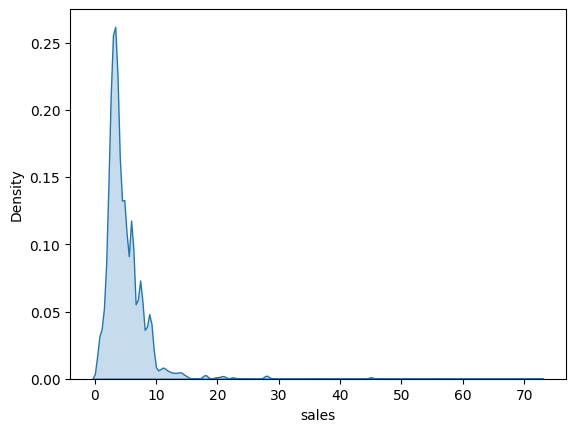

In [75]:
sns.kdeplot(lm['sales'], fill=True)
plt.show()

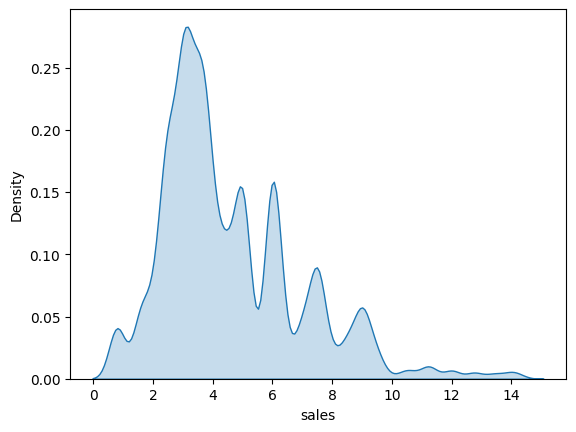

In [76]:
sns.kdeplot(lm_OutlinerRemoved['sales'], fill=True)
plt.show()

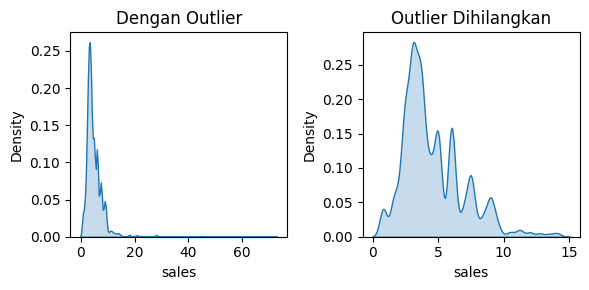

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(6,3))
sns.kdeplot(lm['sales'], fill=True, ax=axes[0])
axes[0].set_title('Dengan Outlier')
sns.kdeplot(lm_OutlinerRemoved['sales'], fill=True, ax=axes[1])
axes[1].set_title('Outlier Dihilangkan')
plt.tight_layout()
plt.show()

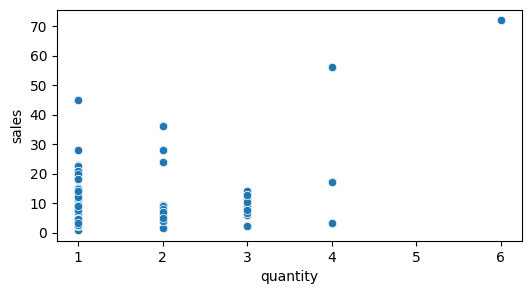

In [93]:
fig= plt.subplots(figsize=(6,3))
sns.scatterplot(x=lm['quantity'], y=lm['sales'])
plt.show()

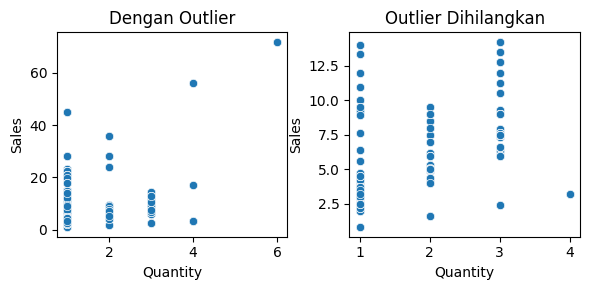

In [96]:
# Buat figure dan 2 axes (subplot)
fig, axes = plt.subplots(1, 2, figsize=(6, 3))  # ukuran disesuaikan agar dua plot muat

# Scatter plot untuk data asli (dengan outlier)
sns.scatterplot(x=lm['quantity'], y=lm['sales'], ax=axes[0])
axes[0].set_title('Dengan Outlier')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Sales')

# Scatter plot untuk data setelah outlier dihapus
sns.scatterplot(x=lm_OutlinerRemoved['quantity'], y=lm_OutlinerRemoved['sales'], ax=axes[1])
axes[1].set_title('Outlier Dihilangkan')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Sales')

plt.tight_layout()
plt.show()

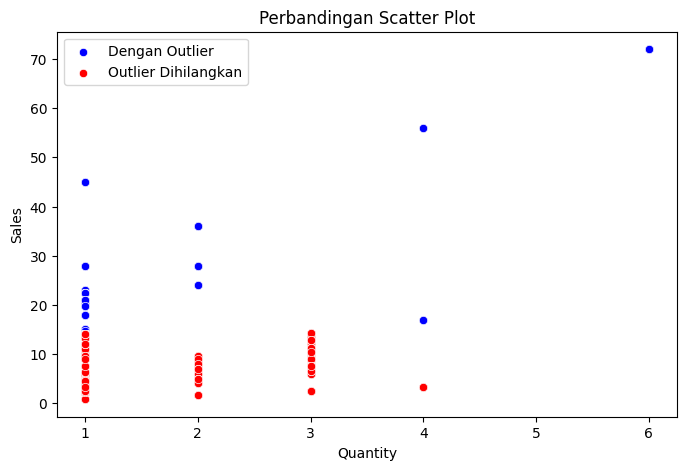

In [100]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=lm['quantity'], y=lm['sales'], color='blue', label='Dengan Outlier')
sns.scatterplot(x=lm_OutlinerRemoved['quantity'], y=lm_OutlinerRemoved['sales'], color='red', label='Outlier Dihilangkan')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.title('Perbandingan Scatter Plot')
plt.show()